In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score, mean_squared_error 


In [2]:
data = pd.read_csv("Salary_Data.csv")
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [3]:
x = data.iloc[:,:-1]
y = data.iloc[:,1]
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.8, random_state=60)

In [4]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9335.94]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.68e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [5]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=5)
x_poly_trian = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)


In [6]:
poly_model = LinearRegression()
poly_model.fit(x_poly_trian, y_train )

y_poly_pred_train = poly_model.predict(x_poly_trian)
y_poly_pred_test = poly_model.predict(x_poly_test)

In [7]:
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1,1)
x_range_poly =poly.transform(x_range) 
y_range_red = poly_model.predict(x_range_poly)

c:\Users\moham\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


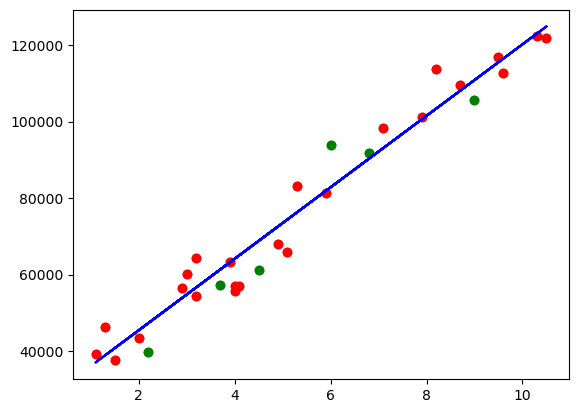

In [ ]:
plt.scatter(x_train, y_train, color ="red")
plt.scatter(x_test, y_test, color ="green")
plt.plot(x_train, lin_reg.predict(x_train), color="blue")

In [11]:
y_lin_pred_train = lin_reg.predict(x_train)
y_lin_pred_test = lin_reg.predict(x_test)
train_r2 = r2_score(y_train, y_lin_pred_train)
test_r2 = r2_score(y_test, y_lin_pred_test)
print("Linear Regression Train R2 Score:", train_r2)
print("Linear Regression Test R2 Score:", test_r2)

Linear Regression Train R2 Score: 0.9642298068583915
Linear Regression Test R2 Score: 0.9139925364405547


In [12]:
train_r2_poly = r2_score(y_train, y_poly_pred_train)
test_r2_poly = r2_score(y_test, y_poly_pred_test)
print("Polynomial Regression Train R2 Score:", train_r2_poly)
print("Polynomial Regression Test R2 Score:", test_r2_poly)

Polynomial Regression Train R2 Score: 0.9707952314954511
Polynomial Regression Test R2 Score: 0.913915598640472
